# Custom User-based Model
The present notebooks aims at creating a UserBased class that inherits from the Algobase class (surprise package) and that can be customized with various similarity metrics, peer groups and score aggregation functions. 

In [4]:
# reloads modules automatically before entering the execution of code
%load_ext autoreload
%autoreload 2

# standard library imports
# -- add new imports here --
import heapq

# third parties imports
import numpy as np 
import pandas as pd
from surprise import AlgoBase

# -- add new imports here --
from surprise import Dataset, Reader
from surprise import KNNWithMeans
from surprise import PredictionImpossible

# local imports
from constants import Constant as C
from loaders import load_ratings
# -- add new imports here --

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 1. Loading Data
Prepare a dataset in order to help implementing a user-based recommender system

In [2]:
# -- load data, build trainset and anti testset --

# 1. Load the ratings as a pandas DataFrame
df = load_ratings()

# 2. Define a Reader object using the scale from your Constant class
# We use C.RATINGS_SCALE which is (0.5, 5.0)
reader = Reader(rating_scale=C.RATINGS_SCALE)

# 3. Convert the DataFrame into a Surprise Dataset
# We use your specific constant names: USER_ID_COL, ITEM_ID_COL, RATING_COL
data = Dataset.load_from_df(df[[C.USER_ID_COL, C.ITEM_ID_COL, C.RATING_COL]], reader)

# 4. Build the trainset using all available ratings
trainset = data.build_full_trainset()

# 5. Build the anti testset
antitestset = trainset.build_anti_testset()

# Verification
print(f"Number of users in trainset: {trainset.n_users}")
print(f"Number of items in trainset: {trainset.n_items}")

Number of users in trainset: 1000
Number of items in trainset: 8737


# 2. Explore Surprise's user-based algorithm
Displays user-based predictions and similarity matrix on the test dataset using the KNNWithMeans class

In [3]:
# -- using surprise's user-based algorithm, explore the impact of different parameters and displays predictions --

# 1. Initial configuration and training
sim_options = {
    'name': 'msd',
    'min_support': 3,
    'user_based': True
}

# k=3: peer group size, min_k=2: minimum neighbors for weighted average
algo = KNNWithMeans(k=3, min_k=2, sim_options=sim_options)
algo.fit(trainset)

# 2. Predict the specific rating for user 11 and item 364
uid = 11
iid = 364
prediction = algo.predict(uid, iid)
print(f"Initial prediction for user {uid} and item {iid}: {prediction.est:.2f}")

# 3. Prediction for all ratings in anti-testset with initial parameters
predictions = algo.test(antitestset)
print("\n--- Initial 30 predictions ---")
for pred in predictions[:30]:
    print(f"User: {pred.uid} | Item: {pred.iid} | Est: {pred.est:.2f} | actual_k: {pred.details.get('actual_k')}")

# 4. Variation of min_k from 1 to 3
for mk in [1, 2, 3]:
    print(f"\n--- Displaying 30 predictions with min_k = {mk} ---")
    algo_mk = KNNWithMeans(k=3, min_k=mk, sim_options=sim_options)
    algo_mk.fit(trainset)
    predictions_mk = algo_mk.test(antitestset)
    for pred in predictions_mk[:30]:
        print(f"User: {pred.uid} | Item: {pred.iid} | Est: {pred.est:.2f} | actual_k: {pred.details.get('actual_k')}")

# 5. Impact of changing min_support from 1 to 3 (with min_k=2)
for ms in [1, 2, 3]:
    print(f"\n--- Impact of min_support = {ms} (displaying first 30) ---")
    s_opts = {'name': 'msd', 'min_support': ms, 'user_based': True}
    temp_algo = KNNWithMeans(k=3, min_k=2, sim_options=s_opts)
    temp_algo.fit(trainset)
    preds_ms = temp_algo.test(antitestset)
    for pred in preds_ms[:30]:
        print(f"User: {pred.uid} | Item: {pred.iid} | Est: {pred.est:.2f} | actual_k: {pred.details.get('actual_k')}")

# 6. Display the similarity matrix
print("\n--- Similarity Matrix ---")
print(algo.sim)

Computing the msd similarity matrix...
Done computing similarity matrix.
Initial prediction for user 11 and item 364: 3.45


KeyboardInterrupt: 

## Effect of `min_k` (1 → 3)

Comparing predictions for `min_k = 1`, `min_k = 2` and `min_k = 3`, we observe that
**the higher `min_k` is, the more some estimates fall back to the user's average rating**.

For example, for user 11 / item 1214:
- `min_k=1` → Est: **3.60** (1 neighbor used)
- `min_k=2` → Est: **3.17** (fallback to user mean, since `actual_k=1 < min_k=2`)
- `min_k=3` → Est: **3.17** (same)

**Why?** `min_k` defines the minimum number of neighbors required to compute a weighted average
prediction. If `actual_k < min_k`, Surprise falls back to the **user's mean rating** as the
default estimate. Increasing `min_k` makes the algorithm more strict, resulting in more
default predictions.

## Effect of `min_support` (1 → 3)

Varying `min_support` while keeping `min_k=2`, we observe that
**`actual_k` decreases as `min_support` increases**.

For example, for user 19 / item 5952:
- `min_support=1` → `actual_k: 3`
- `min_support=2` → `actual_k: 1`
- `min_support=3` → `actual_k: 0`

**What does `actual_k` mean?** It is the **actual number of neighbors effectively used**
when computing the prediction, i.e. the number of neighbors that satisfied all conditions
(non-zero similarity, sufficient co-ratings) at prediction time.

**Why does `actual_k` decrease as `min_support` increases?** `min_support` sets the minimum
number of co-rated items two users must share for their similarity to be non-zero. The higher
this value, the sparser the similarity matrix becomes, and therefore fewer potential neighbors
are available — which reduces `actual_k`.
```

# 3. Implement and explore a customizable user-based algorithm
Create a self-made user-based algorithm allowing to customize the similarity metric, peer group calculation and aggregation function

In [ ]:
class UserBased(AlgoBase):
    def __init__(self, k=3, min_k=1, sim_options={}, **kwargs):
        AlgoBase.__init__(self, sim_options=sim_options, **kwargs)
        self.k = k
        self.min_k = min_k

    def fit(self, trainset):
        AlgoBase.fit(self, trainset)
        
        # 1. Computing the ratings matrix
        self.compute_rating_matrix()
        
        # 2. Compute the similarity matrix
        self.compute_similarity_matrix()
        
        # 3. Computing the mean rating of every user
        self.mean_ratings = []
        for u in range(self.trainset.n_users):
            user_ratings = [r for (_, r) in self.trainset.ur[u]]
            self.mean_ratings.append(np.mean(user_ratings))
        
        return self

    def estimate(self, u, i):
        if not (self.trainset.knows_user(u) and self.trainset.knows_item(i)):
            raise PredictionImpossible('User and/or item is unknown.')
        
        # The estimate is by default set to the user average rating
        estimate = self.mean_ratings[u]
        
        # Step 1: Create the peer group of user u for item i
        # Potential neighbor: (neighbor_inner_id, similarity_value, rating)
        potential_neighbors = []
        
        # Access ratings of item i with self.trainset.ir[i]
        for (v, r_vi) in self.trainset.ir[i]:
            if v == u:
                continue
            
            sim_uv = self.sim[u, v]
            if sim_uv > 0:
                potential_neighbors.append((v, sim_uv, r_vi))
        
        # Pick top neighbors efficiently using heapq
        # Since we want to sort by similarity_value (index 1 of the tuple), 
        # we use a lambda function for the key.
        top_neighbors = heapq.nlargest(self.k, potential_neighbors, key=lambda x: x[1])
        
        # Step 2: Compute the weighted average
        actual_k = len(top_neighbors)
        
        # If actual_k is above min_k, we add the weighted average component
        if actual_k >= self.min_k:
            weighted_sum = 0
            sum_sim = 0
            
            for (v, sim_uv, r_vi) in top_neighbors:
                # Weighted average calculation: sim * (rating - neighbor_mean)
                weighted_sum += sim_uv * (r_vi - self.mean_ratings[v])
                sum_sim += abs(sim_uv)
            
            if sum_sim > 0:
                estimate += (weighted_sum / sum_sim)
        
        return estimate

    def compute_rating_matrix(self):
        m = self.trainset.n_users
        n = self.trainset.n_items
        
        # Preallocate an mxn numpy array with NaN
        self.ratings_matrix = np.empty((m, n))
        self.ratings_matrix[:] = np.nan
        
        # Access ratings of a specific user with self.trainset.ur[uiid]
        for uiid in range(m):
            for (iiid, rating) in self.trainset.ur[uiid]:
                self.ratings_matrix[uiid, iiid] = rating

    def compute_similarity_matrix(self):
        m = self.trainset.n_users
        self.sim = np.eye(m)
        min_support = self.sim_options.get('min_support', 1)
        
        # Retrieve the similarity metric name from sim_options (default: msd)
        sim_name = self.sim_options.get('name', 'msd').lower()
        
        for i in range(m):
            for j in range(i + 1, m):
                row_i = self.ratings_matrix[i]
                row_j = self.ratings_matrix[j]
                
                # Intersection: items rated by BOTH users
                mask_intersection = ~np.isnan(row_i - row_j)
                support = np.sum(mask_intersection)
                
                if support >= min_support:
                    if sim_name == 'msd':
                        # Ta logique MSD actuelle
                        sq_diff = np.sum((row_i[mask_intersection] - row_j[mask_intersection])**2)
                        msd = sq_diff / support
                        similarity = 1 / (msd + 1)
                    
                    elif sim_name == 'jacard':
                        # Logique Jaccard : intersection / union
                        mask_union = ~np.isnan(row_i) | ~np.isnan(row_j)
                        union_count = np.sum(mask_union)
                        similarity = support / union_count if union_count > 0 else 0
                    
                    self.sim[i, j] = similarity
                    self.sim[j, i] = similarity
        

# 4. Compare KNNWithMeans with UserBased
Try to replicate KNNWithMeans with your self-made UserBased and check that outcomes are identical

In [ ]:
# -- assert that predictions are the same with different sim_options --

# 1. Initialize both algorithms with identical parameters
sim_options = {'name': 'msd', 'min_support': 3, 'user_based': True}

# KNNWithMeans (Surprise official)
algo_official = KNNWithMeans(k=3, min_k=2, sim_options=sim_options)
algo_official.fit(trainset)

# UserBased (Custom replication)
algo_custom = UserBased(k=3, min_k=2, sim_options=sim_options)
algo_custom.fit(trainset)

# 2. Compute predictions for the first 30 entries of the anti-testset
preds_official = algo_official.test(antitestset[:30])
preds_custom = algo_custom.test(antitestset[:30])

# 3. Display the results in a formatted table
print(f"{'User ID':<8} | {'Item ID':<8} | {'KNNWithMeans':<15} | {'UserBased':<15}")
print("-" * 55)

for p_off, p_cust in zip(preds_official, preds_custom):
    # Print estimates with 4 decimal places to ensure precision match
    print(f"{p_off.uid:<8} | {p_off.iid:<8} | {p_off.est:<15.4f} | {p_cust.est:<15.4f}")

# 4. Final verification of the specific target
target_official = algo_official.predict(11, 364).est
target_custom = algo_custom.predict(11, 364).est

print("-" * 55)
print(f"Target (11, 364) check -> Official: {target_official:.4f} | Custom: {target_custom:.4f}")

Computing the msd similarity matrix...
Done computing similarity matrix.
User ID  | Item ID  | KNNWithMeans    | UserBased      
-------------------------------------------------------
11       | 1214     | 3.1667          | 3.1667         
11       | 364      | 2.4920          | 2.4920         
11       | 4308     | 3.1667          | 3.1667         
11       | 527      | 3.8989          | 3.8989         
13       | 1997     | 2.8000          | 2.8000         
13       | 4993     | 2.8000          | 2.8000         
13       | 2700     | 2.8000          | 2.8000         
13       | 1721     | 2.8000          | 2.8000         
13       | 527      | 2.8000          | 2.8000         
17       | 2028     | 3.8125          | 3.8125         
17       | 4993     | 4.1283          | 4.1283         
17       | 1214     | 3.2500          | 3.2500         
17       | 4308     | 3.2500          | 3.2500         
19       | 1997     | 3.5000          | 3.5000         
19       | 2028     | 3.5000   

# 5. Compare MSD and Jacard
Compare predictions made with MSD similarity and Jacard similarity


In [ ]:
# -- compare predictions made with MSD similarity and Jacard similarity --

# Configuration for MSD
sim_msd = {'name': 'msd', 'min_support': 3, 'user_based': True}
algo_msd = UserBased(k=3, min_k=2, sim_options=sim_msd)
algo_msd.fit(trainset)
pred_msd = algo_msd.predict(11, 364)

# Configuration for Jaccard
sim_jac = {'name': 'jacard', 'min_support': 3, 'user_based': True}
algo_jac = UserBased(k=3, min_k=2, sim_options=sim_jac)
algo_jac.fit(trainset)
pred_jac = algo_jac.predict(11, 364)

print(f"Prediction (User 11, Item 364) with MSD:     {pred_msd.est:.4f}")
print(f"Prediction (User 11, Item 364) with Jaccard: {pred_jac.est:.4f}")

# Optional: compare the first 5 predictions of the anti-testset
print("\nFirst 5 anti-testset comparisons:")
test_msd = algo_msd.test(antitestset[:5])
test_jac = algo_jac.test(antitestset[:5])

for p_m, p_j in zip(test_msd, test_jac):
    print(f"User {p_m.uid} | Item {p_m.iid} | MSD: {p_m.est:.4f} | Jaccard: {p_j.est:.4f}")


Prediction (User 11, Item 364) with MSD:     2.4920
Prediction (User 11, Item 364) with Jaccard: 2.1667

First 5 anti-testset comparisons:
User 11 | Item 1214 | MSD: 3.1667 | Jaccard: 3.1667
User 11 | Item 364 | MSD: 2.4920 | Jaccard: 2.1667
User 11 | Item 4308 | MSD: 3.1667 | Jaccard: 3.1667
User 11 | Item 527 | MSD: 3.8989 | Jaccard: 4.0556
User 13 | Item 1997 | MSD: 2.8000 | Jaccard: 2.8000


## Our fine-tuned User-based model 
Below you'll find our fine-tuned user-based model

In [5]:
class UserBased_tuned(AlgoBase):
    def __init__(self, k=40, min_k=5, sim_options={}, **kwargs):
        AlgoBase.__init__(self, sim_options=sim_options, **kwargs)
        self.k = k
        self.min_k = min_k

    def fit(self, trainset):
        AlgoBase.fit(self, trainset)
        
        # 1. Computing the ratings matrix
        self.compute_rating_matrix()
        
        # 2. Compute the similarity matrix
        self.compute_similarity_matrix()
        
        # 3. Computing the mean rating of every user
        self.mean_ratings = []
        for u in range(self.trainset.n_users):
            user_ratings = [r for (_, r) in self.trainset.ur[u]]
            self.mean_ratings.append(np.mean(user_ratings))
        
        return self

    def estimate(self, u, i):
        if not (self.trainset.knows_user(u) and self.trainset.knows_item(i)):
            raise PredictionImpossible('User and/or item is unknown.')
        
        # The estimate is by default set to the user average rating
        estimate = self.mean_ratings[u]
        
        # Step 1: Create the peer group of user u for item i
        # Potential neighbor: (neighbor_inner_id, similarity_value, rating)
        potential_neighbors = []
        
        # Access ratings of item i with self.trainset.ir[i]
        for (v, r_vi) in self.trainset.ir[i]:
            if v == u:
                continue
            
            sim_uv = self.sim[u, v]
            if sim_uv > 0:
                potential_neighbors.append((v, sim_uv, r_vi))
        
        # Pick top neighbors efficiently using heapq
        top_neighbors = heapq.nlargest(self.k, potential_neighbors, key=lambda x: x[1])
        
        # Step 2: Compute the weighted average
        actual_k = len(top_neighbors)
        
        # If actual_k is above min_k, we add the weighted average component
        if actual_k >= self.min_k:
            weighted_sum = 0
            sum_sim = 0
            
            for (v, sim_uv, r_vi) in top_neighbors:
                # Weighted average calculation: sim * (rating - neighbor_mean)
                weighted_sum += sim_uv * (r_vi - self.mean_ratings[v])
                sum_sim += abs(sim_uv)
            
            if sum_sim > 0:
                estimate += (weighted_sum / sum_sim)
        
        return estimate

    def compute_rating_matrix(self):
        m = self.trainset.n_users
        n = self.trainset.n_items
        
        # Preallocate an mxn numpy array with NaN
        self.ratings_matrix = np.empty((m, n))
        self.ratings_matrix[:] = np.nan
        
        # Access ratings of a specific user with self.trainset.ur[uiid]
        for uiid in range(m):
            for (iiid, rating) in self.trainset.ur[uiid]:
                self.ratings_matrix[uiid, iiid] = rating

    def compute_similarity_matrix(self):
        m = self.trainset.n_users
        self.sim = np.eye(m)
        min_support = self.sim_options.get('min_support', 5)
        
        # Retrieve the similarity metric name from sim_options (default: msd)
        sim_name = self.sim_options.get('name', 'msd').lower()
        
        for i in range(m):
            for j in range(i + 1, m):
                row_i = self.ratings_matrix[i]
                row_j = self.ratings_matrix[j]
                
                # Intersection: items rated by BOTH users
                mask_intersection = ~np.isnan(row_i - row_j)
                support = np.sum(mask_intersection)
                
                # FIX CRITIQUE : Assigne une valeur par défaut locale immédiate.
                # Cela élimine définitivement le UnboundLocalError.
                current_similarity = 0.0
                
                if support >= min_support:
                    if sim_name == 'msd':
                        sq_diff = np.sum((row_i[mask_intersection] - row_j[mask_intersection])**2)
                        msd = sq_diff / support
                        current_similarity = 1 / (msd + 1)
                    
                    elif sim_name == 'jacard':
                        mask_union = ~np.isnan(row_i) | ~np.isnan(row_j)
                        union_count = np.sum(mask_union)
                        current_similarity = support / union_count if union_count > 0 else 0.0
                    
                    elif sim_name == 'cosine_jaccard':
                        # 1. Extraction des vecteurs sur l'intersection
                        u_vec = row_i[mask_intersection]
                        v_vec = row_j[mask_intersection]
                        
                        # 2. Calcul du Cosinus de base
                        dot_product = np.sum(u_vec * v_vec)
                        norm_u = np.sqrt(np.sum(u_vec**2))
                        norm_v = np.sqrt(np.sum(v_vec**2))
                        cosine = dot_product / (norm_u * norm_v) if (norm_u * norm_v) > 0 else 0.0
                        
                        # 3. Calcul de l'indice de Jaccard
                        mask_union = ~np.isnan(row_i) | ~np.isnan(row_j)
                        union_count = np.sum(mask_union)
                        jaccard = support / union_count if union_count > 0 else 0.0
                        
                        # 4. Fusion des deux métriques
                        current_similarity = float(cosine * jaccard)
                    
                # Assignation sécurisée dans la matrice globale
                self.sim[i, j] = current_similarity
                self.sim[j, i] = current_similarity

# Testing hyperparameters for KNNBaseline

Below you can find the impact of various hyperparameter values for the KNNBaseline used in our Recommender System. Note that those values have been then adapted to satisfied the required metrics.

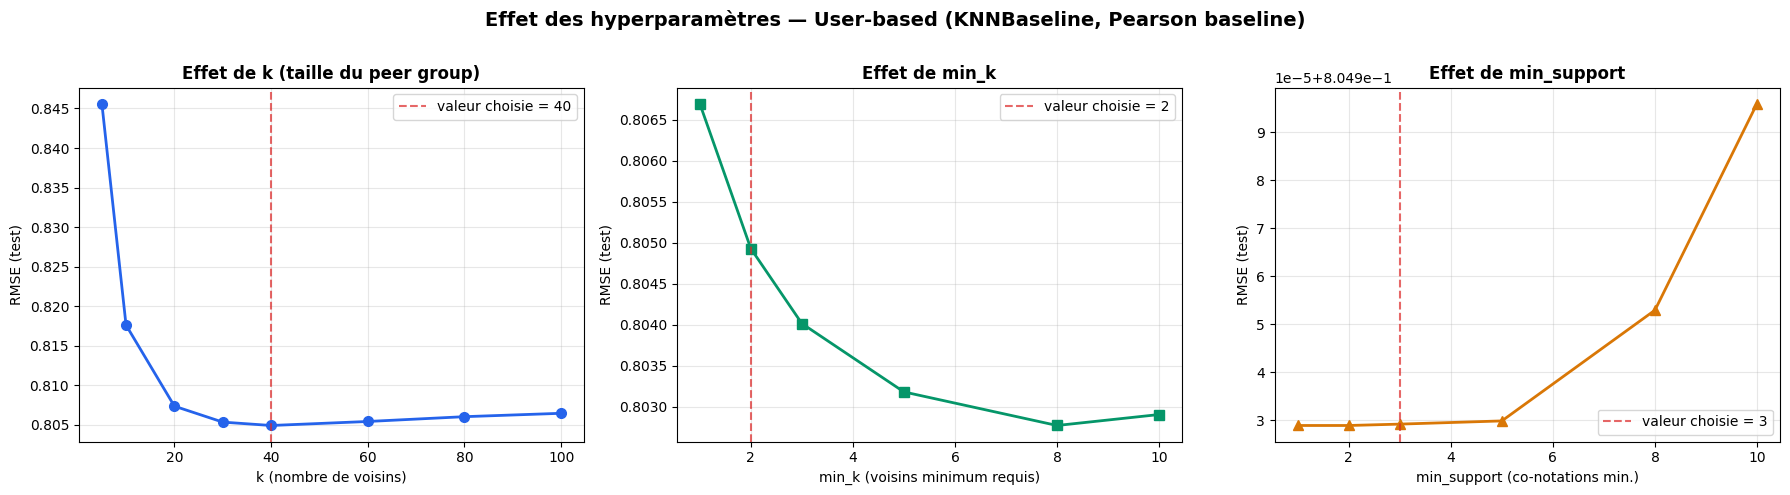

k           : {5: 0.8456, 10: 0.8176, 20: 0.8074, 30: 0.8054, 40: 0.8049, 60: 0.8054, 80: 0.806, 100: 0.8065}
min_k       : {1: 0.8067, 2: 0.8049, 3: 0.804, 5: 0.8032, 8: 0.8028, 10: 0.8029}
min_support : {1: 0.8049, 2: 0.8049, 3: 0.8049, 5: 0.8049, 8: 0.805, 10: 0.805}


In [2]:
# ============================================================
# Effet des hyperparamètres — User-based (KNNBaseline, Pearson baseline)
# -> k (taille du peer group), min_k et min_support
# Modèle de production : UserBased_Pearson_Natif (k=40, min_k=2, min_support=3)
# ============================================================
import matplotlib.pyplot as plt
from surprise import KNNBaseline, accuracy
from surprise.model_selection import train_test_split
from loaders import load_ratings

# Split train/test 75/25 (cohérent avec EvalConfig.test_size)
data = load_ratings(surprise_format=True)
trainset_hp, testset_hp = train_test_split(data, test_size=0.25, random_state=42)

# Grilles testées
k_values      = [5, 10, 20, 30, 40, 60, 80, 100]
mink_values   = [1, 2, 3, 5, 8, 10]
minsup_values = [1, 2, 3, 5, 8, 10]

# --- k et min_k : utilisés au moment de la prédiction -> 1 seul fit suffit ---
# (changer k/min_k ne recalcule PAS la similarité, faite ici avec min_support=3)
algo = KNNBaseline(k=40, min_k=2,
                    sim_options={'name': 'pearson_baseline', 'user_based': True, 'min_support': 3},
                    verbose=False)
algo.fit(trainset_hp)

def rmse_km(k, min_k):
    algo.k, algo.min_k = k, min_k
    return accuracy.rmse(algo.test(testset_hp), verbose=False)

rmse_k    = [rmse_km(k, 2)   for k in k_values]
rmse_mink = [rmse_km(40, mk) for mk in mink_values]

# --- min_support : modifie la similarité -> refit nécessaire à chaque valeur ---
def rmse_minsup(ms):
    a = KNNBaseline(k=40, min_k=2,
                    sim_options={'name': 'pearson_baseline', 'user_based': True, 'min_support': ms},
                    verbose=False)
    a.fit(trainset_hp)
    return accuracy.rmse(a.test(testset_hp), verbose=False)

rmse_ms = [rmse_minsup(ms) for ms in minsup_values]

# --- Visualisation ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Effet des hyperparamètres — User-based (KNNBaseline, Pearson baseline)",
            fontsize=14, fontweight='bold')

for ax, x, y, default, title, xlabel, c, mk in [
    (axes[0], k_values,      rmse_k,    40, "Effet de k (taille du peer group)", "k (nombre de voisins)",
'#2563EB', 'o'),
    (axes[1], mink_values,   rmse_mink,  2, "Effet de min_k",                    "min_k (voisins minimum requis)",
'#059669', 's'),
    (axes[2], minsup_values, rmse_ms,    3, "Effet de min_support",              "min_support (co-notations min.)",
'#D97706', '^'),
]:
    ax.plot(x, y, marker=mk, color=c, linewidth=2, markersize=7)
    ax.axvline(default, color='#DC2626', linestyle='--', alpha=0.7, label=f'valeur choisie = {default}')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(xlabel); ax.set_ylabel("RMSE (test)")
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Récap chiffré
print("k           :", dict(zip(k_values,      [round(v, 4) for v in rmse_k])))
print("min_k       :", dict(zip(mink_values,   [round(v, 4) for v in rmse_mink])))
print("min_support :", dict(zip(minsup_values, [round(v, 4) for v in rmse_ms])))


# 7. Génération des artefacts backend
Sauvegarde le modèle entraîné et les données nécessaires pour que le serveur FastAPI puisse faire des recommandations en temps réel.

In [3]:
import pickle
import numpy as np
from pathlib import Path
from scipy.sparse import csr_matrix, save_npz
from surprise import KNNBaseline  # import depuis models.py pour que le pickle soit rechargeable

ARTIFACTS_DIR = Path("backend/artifacts")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# Entraînement sur le trainset complet (trainset est déjà chargé depuis la section 1)
# Note : le fit() calcule la matrice de similarité (~5 min pour 1000 users) — à faire une seule fois
print("Entraînement de UserBased_tuned...")
ub_algo = KNNBaseline(k=40, min_k=2, sim_options={'name': 'pearson_baseline', 'min_support': 3})
ub_algo.fit(trainset)
print("Entraînement terminé.")

ts = ub_algo.trainset

# 1. Matrice de ratings sparse (n_users × n_items)
print("Sauvegarde de rating_matrix.npz...")
rows, cols, vals = [], [], []
for u in range(ts.n_users):
    for iid, r in ts.ur[u]:
        rows.append(u)
        cols.append(iid)
        vals.append(r)
R = csr_matrix((vals, (rows, cols)), shape=(ts.n_users, ts.n_items))
save_npz(ARTIFACTS_DIR / "rating_matrix.npz", R)

# 2. Moyenne de rating par utilisateur
print("Sauvegarde de user_means.npy...")
means = np.array([np.mean([r for _, r in ts.ur[u]]) for u in range(ts.n_users)])
np.save(ARTIFACTS_DIR / "user_means.npy", means)

# 3. Modèle pickled (utilisé par le backend uniquement pour accéder au trainset)
print("Sauvegarde de userbased_model.pkl...")
with open(ARTIFACTS_DIR / "userbased_model.pkl", "wb") as f:
    pickle.dump(ub_algo, f)

print(f"\nArtefacts sauvegardés dans {ARTIFACTS_DIR}/")
print(f"  rating_matrix.npz  — {ts.n_users} users × {ts.n_items} items")
print(f"  user_means.npy     — {ts.n_users} valeurs")
print(f"  userbased_model.pkl")

Entraînement de UserBased_tuned...
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Entraînement terminé.
Sauvegarde de rating_matrix.npz...
Sauvegarde de user_means.npy...
Sauvegarde de userbased_model.pkl...

Artefacts sauvegardés dans backend/artifacts/
  rating_matrix.npz  — 1000 users × 8737 items
  user_means.npy     — 1000 valeurs
  userbased_model.pkl
